<a href="https://colab.research.google.com/github/tanjiro-01/real_estate_cf/blob/main/realEstateCFmain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real Estate Underwriting Score Prediction System
Thejaswi Bhat H

CodeFrontier Software

Objective: Build a Machine Learning model to predict an underwriting score (0–100) and categorize risk levels for real estate investment decisions.

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/CF/task1_main/data/data.xlsx"
df = pd.read_excel(file_path)

df.head()
df.shape
df.info()
df.describe()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   property_id                500 non-null    object 
 1   city                       500 non-null    object 
 2   builder_name               500 non-null    object 
 3   builder_years_in_business  500 non-null    int64  
 4   projects_completed         500 non-null    int64  
 5   avg_delay_months           500 non-null    float64
 6   debt_to_equity_ratio       500 non-null    float64
 7   rera_violations            500 non-null    int64  
 8   litigation_count           500 non-null    int64  
 9   is_publicly_listed         500 non-null    int64  
 10  net_worth_crores           500 non-null    int64  
 11  city_tier                  500 no

,builder_years_in_business,projects_completed,avg_delay_months,debt_to_equity_ratio,rera_violations,litigation_count,is_publicly_listed,net_worth_crores,city_tier,distance_to_metro_km,...,holding_period_months,loan_to_value_pct,interest_rate_pct,expected_rental_yield,builder_score,property_score,market_score,financial_score,underwriting_score,expected_irr_pct
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,23.02800,67.468000,5.967400,1.355540,1.658000,3.284000,0.616000,4699.992000,1.378000,7.530200,...,42.264000,39.701000,9.545400,3.512200,74.917000,59.540000,61.127000,64.575000,65.652200,9.577800
std,11.56801,55.232402,4.650994,0.694497,2.142479,3.798447,0.486845,3258.731066,0.485373,4.302708,...,20.333746,23.245197,1.130803,1.181229,13.402797,8.406887,12.731794,12.618491,9.914653,6.111864
min,2.00000,1.000000,0.000000,0.240000,0.000000,0.000000,0.000000,50.000000,1.000000,0.200000,...,12.000000,0.400000,7.500000,1.100000,30.000000,39.500000,29.500000,38.500000,29.600000,-5.600000
25%,14.75000,23.000000,3.200000,0.920000,0.000000,1.000000,0.000000,2629.000000,1.000000,3.800000,...,24.000000,19.000000,8.575000,2.575000,72.500000,54.500000,53.000000,55.500000,61.675000,4.700000
50%,23.00000,57.000000,5.000000,1.180000,1.000000,2.000000,1.000000,3961.000000,1.000000,7.600000,...,36.000000,39.050000,9.500000,3.500000,77.500000,58.500000,61.000000,64.000000,67.050000,9.700000
75%,32.00000,86.250000,7.300000,1.570000,2.000000,4.000000,1.000000,6528.750000,2.000000,11.400000,...,60.000000,59.625000,10.500000,4.500000,83.500000,64.500000,70.000000,74.500000,72.000000,14.400000
max,47.00000,205.000000,28.000000,3.880000,12.000000,23.000000,1.000000,12483.000000,2.000000,15.000000,...,72.000000,79.800000,11.500000,6.000000,97.000000,88.500000,95.500000,95.000000,86.800000,23.600000


In [ ]:
# Dataset shape
print("Shape:", df.shape)

# First 5 rows
df.head()


Shape: (500, 43)


,property_id,city,builder_name,builder_years_in_business,projects_completed,avg_delay_months,debt_to_equity_ratio,rera_violations,litigation_count,is_publicly_listed,...,payment_plan_type,builder_score,property_score,market_score,financial_score,underwriting_score,risk_category,expected_irr_pct,recommendation,confidence_level
0,VAD-2024-0001,Vadodara,Mahindra Lifespaces,18,40,4.4,0.50,0,0,1,...,CLP,92.5,67.5,54.0,40.0,70.5,Moderate Risk,3.2,INVEST,High
1,SUR-2024-0002,Surat,Local Builder 1,9,13,6.7,2.64,1,7,0,...,CLP,54.0,51.5,57.5,55.5,44.1,High Risk,2.9,AVOID,High
2,BAN-2024-0003,Bangalore,Piramal Realty,10,10,4.1,1.07,0,0,1,...,CLP,77.5,74.5,43.5,48.0,68.8,Moderate Risk,4.8,INVEST,Medium
3,IND-2024-0004,Indore,Jaypee Group,26,54,28.0,3.32,9,19,0,...,SUB,44.0,52.5,62.5,63.0,36.5,High Risk,14.7,AVOID,High
4,MUM-2024-0005,Mumbai,Prestige Group,30,93,1.3,1.30,0,0,1,...,CLP,86.5,57.5,71.0,76.0,74.2,Moderate Risk,15.6,INVEST,Medium


In [ ]:
# Info
df.info()

# Check missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   property_id                500 non-null    object 
 1   city                       500 non-null    object 
 2   builder_name               500 non-null    object 
 3   builder_years_in_business  500 non-null    int64  
 4   projects_completed         500 non-null    int64  
 5   avg_delay_months           500 non-null    float64
 6   debt_to_equity_ratio       500 non-null    float64
 7   rera_violations            500 non-null    int64  
 8   litigation_count           500 non-null    int64  
 9   is_publicly_listed         500 non-null    int64  
 10  net_worth_crores           500 non-null    int64  
 11  city_tier                  500 non-null    int64  
 12  distance_to_metro_km       500 non-null    float64
 13  distance_to_cbd_km         500 non-null    float64

,0
property_id,0
city,0
builder_name,0
builder_years_in_business,0
projects_completed,0
avg_delay_months,0
debt_to_equity_ratio,0
rera_violations,0
litigation_count,0
is_publicly_listed,0


In [ ]:
#missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

missing_percent = (df.isnull().sum()/len(df))*100
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

missing_report.head(15)



,missing_count,missing_percent
property_id,0,0.0
city,0,0.0
builder_name,0,0.0
builder_years_in_business,0,0.0
projects_completed,0,0.0
avg_delay_months,0,0.0
debt_to_equity_ratio,0,0.0
rera_violations,0,0.0
litigation_count,0,0.0
is_publicly_listed,0,0.0


In [ ]:
#duplicate check
df.duplicated().sum()



np.int64(0)

In [ ]:
df["underwriting_score"].describe()

,underwriting_score
count,500.000000
mean,65.652200
std,9.914653
min,29.600000
25%,61.675000
50%,67.050000
75%,72.000000
max,86.800000


In [ ]:
df["risk_category"].value_counts()


,count
risk_category,
Moderate Risk,303
Medium-High Risk,136
High Risk,41
Low Risk,15
Avoid,5


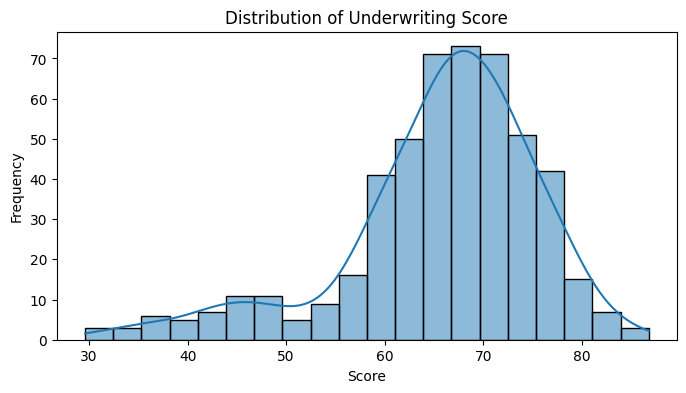

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df["underwriting_score"], bins=20, kde=True)
plt.title("Distribution of Underwriting Score")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


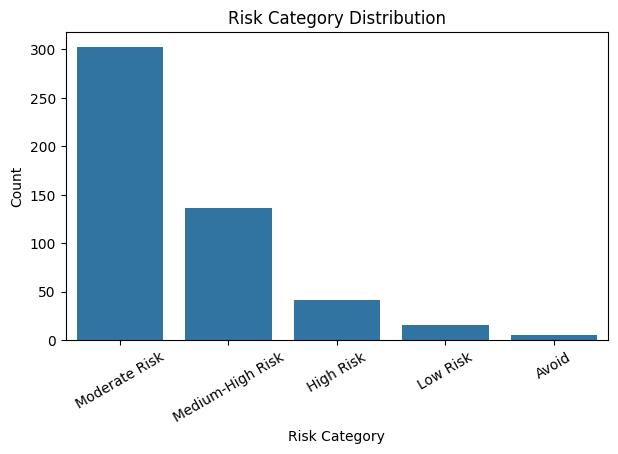

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x="risk_category",
    order=df["risk_category"].value_counts().index
)
plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()


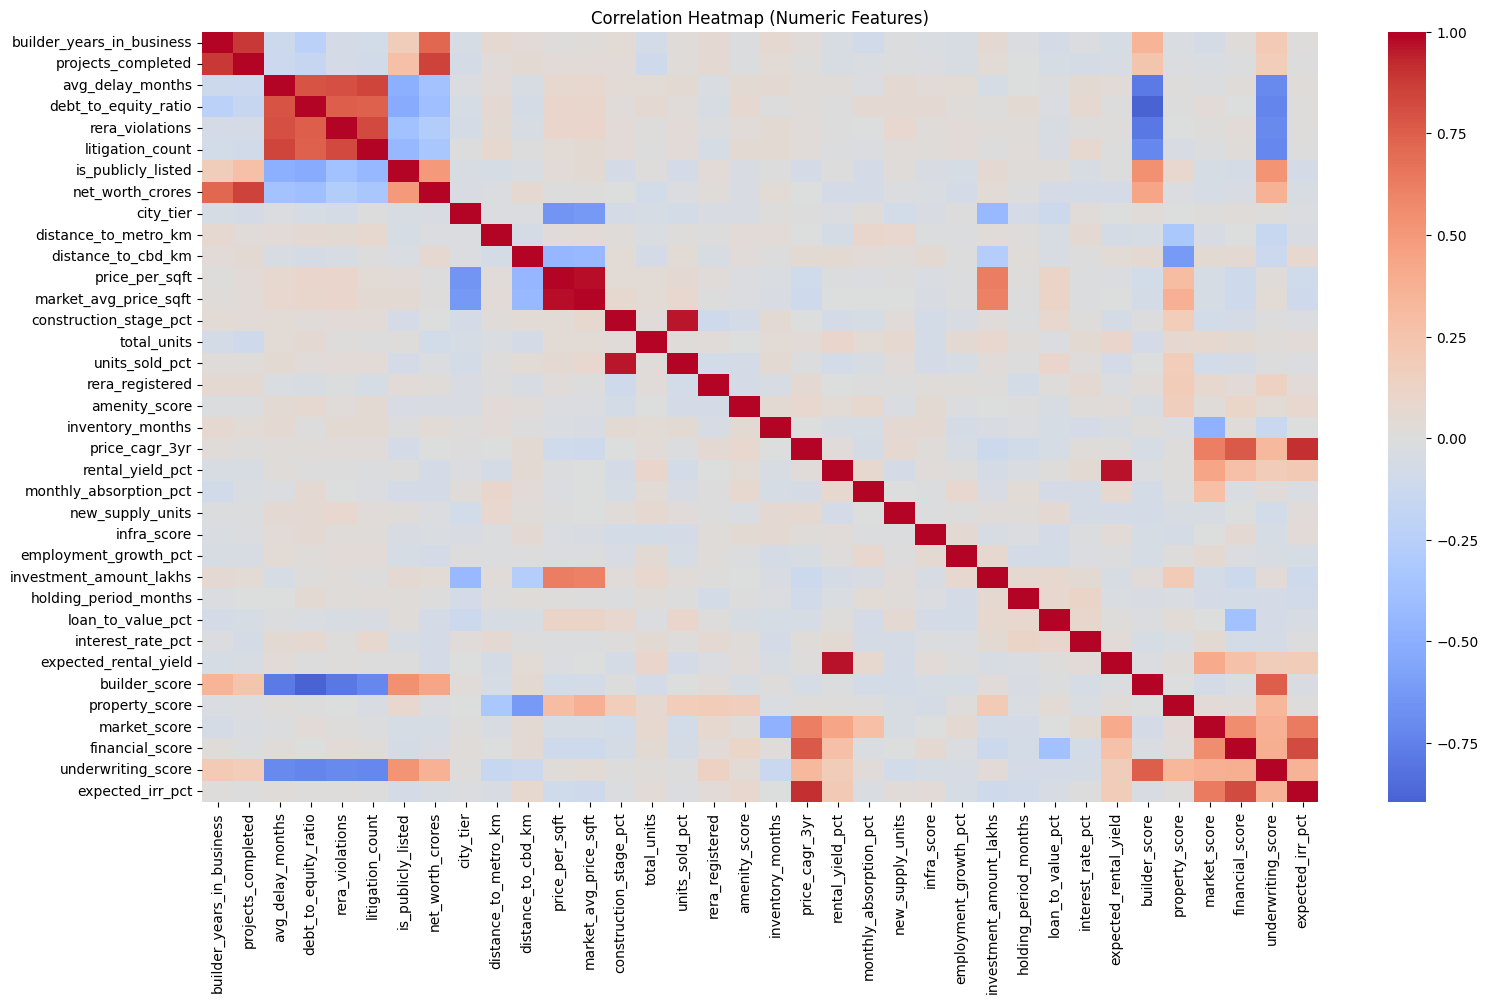

In [ ]:
plt.figure(figsize=(18,10))

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [ ]:
# Separate columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

num_cols, cat_cols


Numerical Columns: 36
Categorical Columns: 7


(Index(['builder_years_in_business', 'projects_completed', 'avg_delay_months',
        'debt_to_equity_ratio', 'rera_violations', 'litigation_count',
        'is_publicly_listed', 'net_worth_crores', 'city_tier',
        'distance_to_metro_km', 'distance_to_cbd_km', 'price_per_sqft',
        'market_avg_price_sqft', 'construction_stage_pct', 'total_units',
        'units_sold_pct', 'rera_registered', 'amenity_score',
        'inventory_months', 'price_cagr_3yr', 'rental_yield_pct',
        'monthly_absorption_pct', 'new_supply_units', 'infra_score',
        'employment_growth_pct', 'investment_amount_lakhs',
        'holding_period_months', 'loan_to_value_pct', 'interest_rate_pct',
        'expected_rental_yield', 'builder_score', 'property_score',
        'market_score', 'financial_score', 'underwriting_score',
        'expected_irr_pct'],
       dtype='object'),
 Index(['property_id', 'city', 'builder_name', 'payment_plan_type',
        'risk_category', 'recommendation', 'confidence_

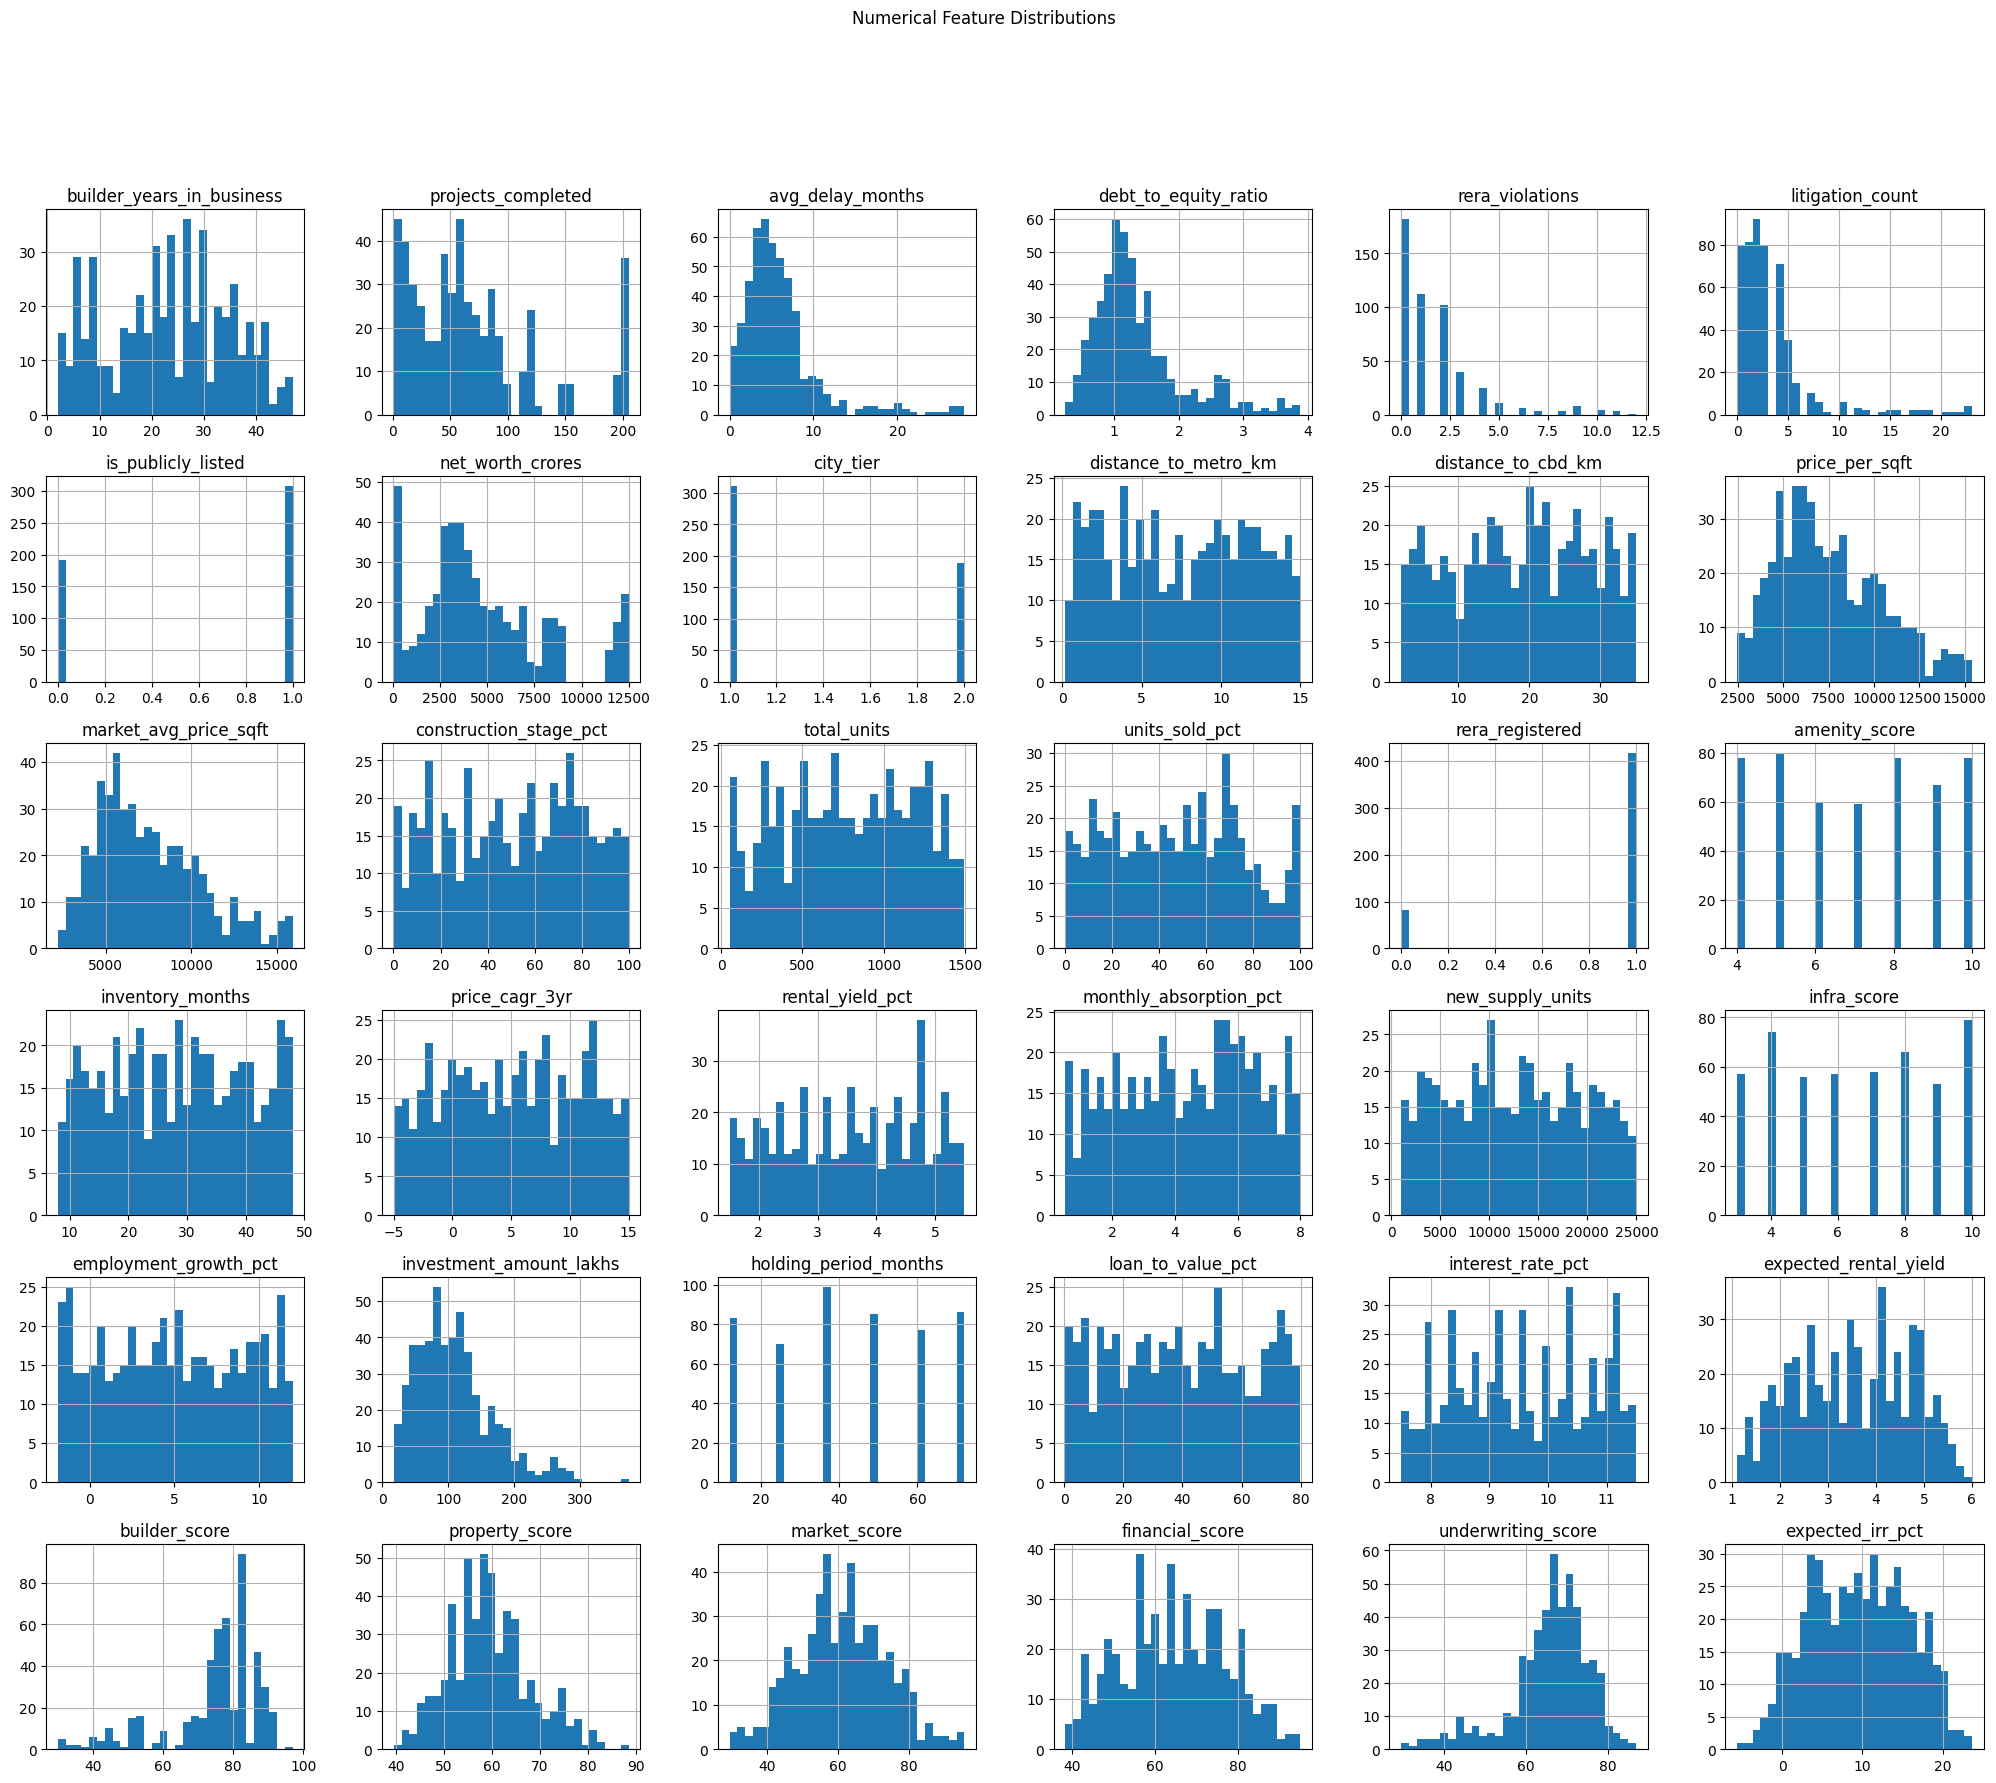

In [ ]:
df[num_cols].hist(figsize=(25,20), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.show()


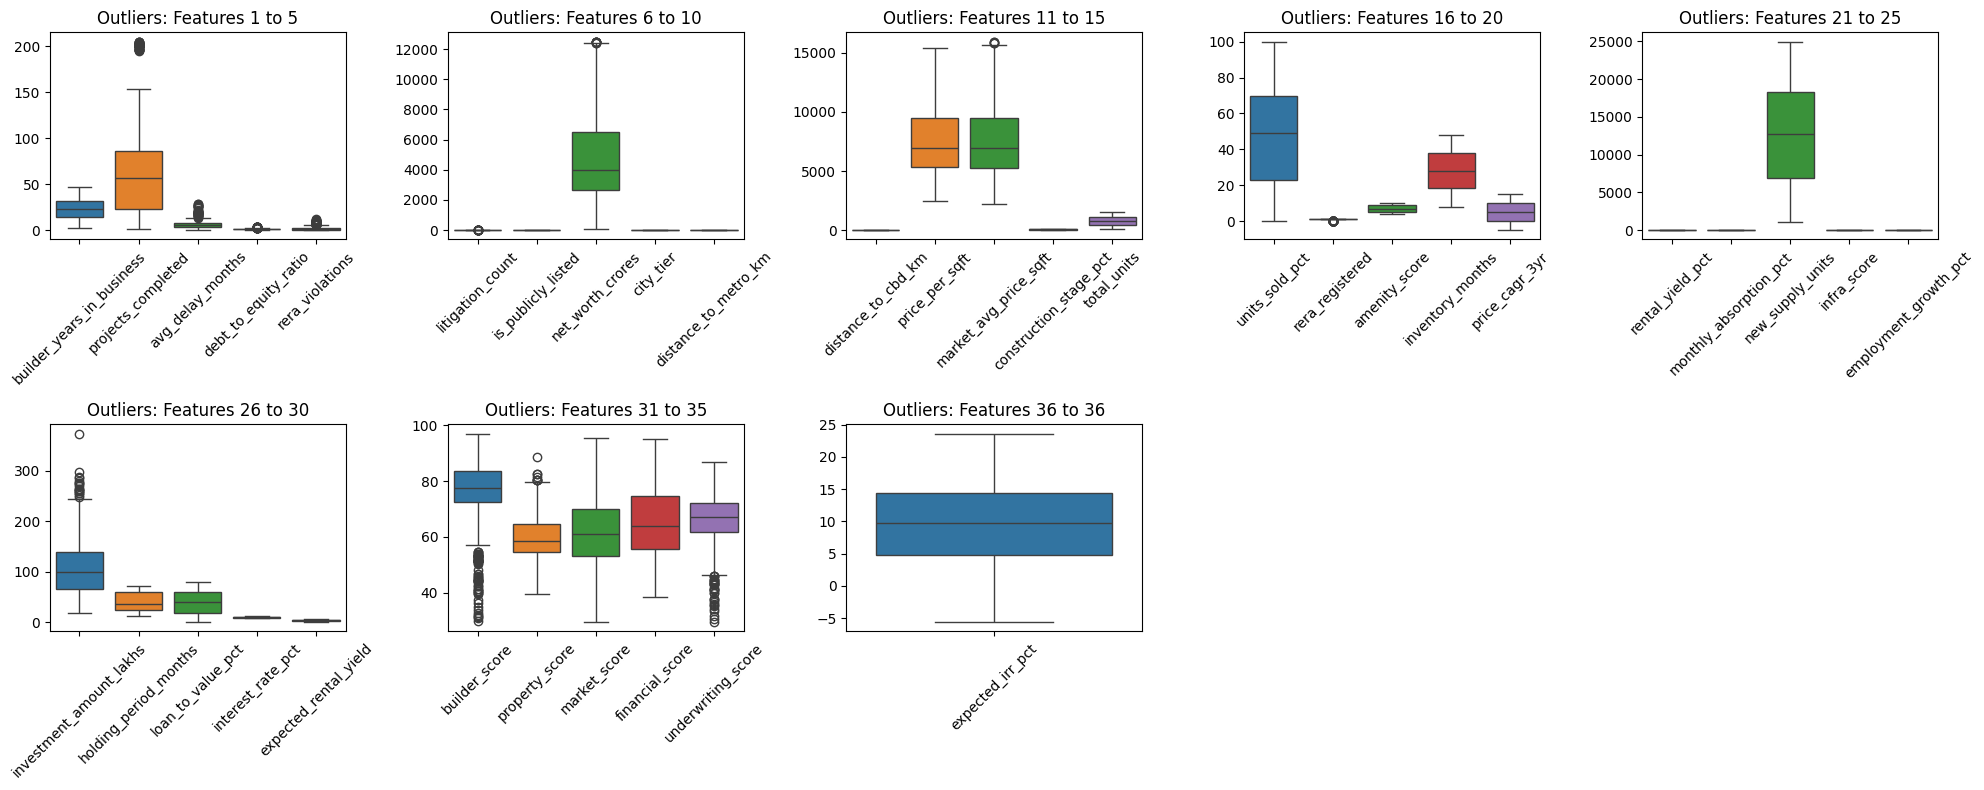

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64']).columns
batch_size = 5

# 1. Calculate how many total plots (batches) we need
num_batches = math.ceil(len(num_cols) / batch_size)

# 2. Define the grid layout (5 columns)
grid_cols = 5
grid_rows = math.ceil(num_batches / grid_cols)

# 3. Create the figure and the axes grid
# Increased width to 20 so the 5 columns aren't squished together
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 4 * grid_rows))

# Flatten the axes array to make it easy to loop through
# (Ensures it works whether grid_rows is 1 or more)
import numpy as np
axes = np.array(axes).flatten()

for i in range(num_batches):
    start_idx = i * batch_size
    batch = num_cols[start_idx : start_idx + batch_size]

    # 4. Draw the plot on the specific axis (axes[i])
    sns.boxplot(data=df[batch], ax=axes[i])

    # 5. Set titles and tick rotations for the specific axis
    axes[i].set_title(f"Outliers: Features {start_idx+1} to {start_idx+len(batch)}")
    axes[i].tick_params(axis='x', rotation=45)

# 6. Hide any extra empty subplots if the grid isn't perfectly filled
for j in range(num_batches, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import zscore

df_z = df.copy()

z_scores = np.abs(zscore(df_z[num_cols]))

df_z_clean = df_z[(z_scores < 3).all(axis=1)]

print("Original:", df.shape)
print("After Z-score:", df_z_clean.shape)

Original: (500, 43)
After Z-score: (468, 43)


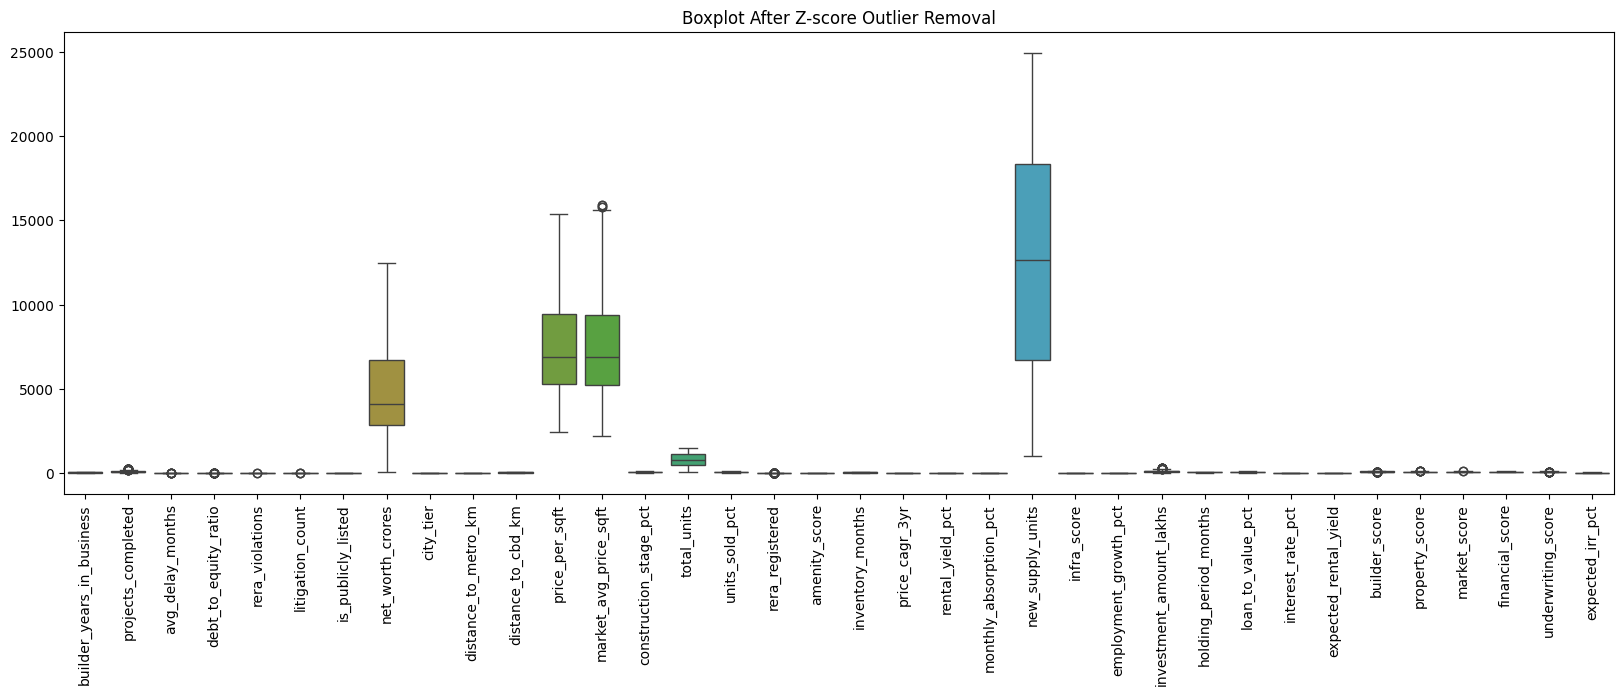

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data=df_z_clean[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot After Z-score Outlier Removal")
plt.show()

In [ ]:
# 1. Start fresh with the full dataset
df_clean = df.copy()

# 2. Identify numeric columns
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

# 3. Calculate IQR based on the data
Q1 = df_clean[num_cols].quantile(0.25)
Q3 = df_clean[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


for col in num_cols:
    df_clean[col] = df_clean[col].clip(lower=lower_bound[col], upper=upper_bound[col])

# 5. Verify the results
print("Original shape:", df.shape)
print("Cleaned shape (Capped):", df_clean.shape)

Original shape: (500, 43)
Cleaned shape (Capped): (500, 43)


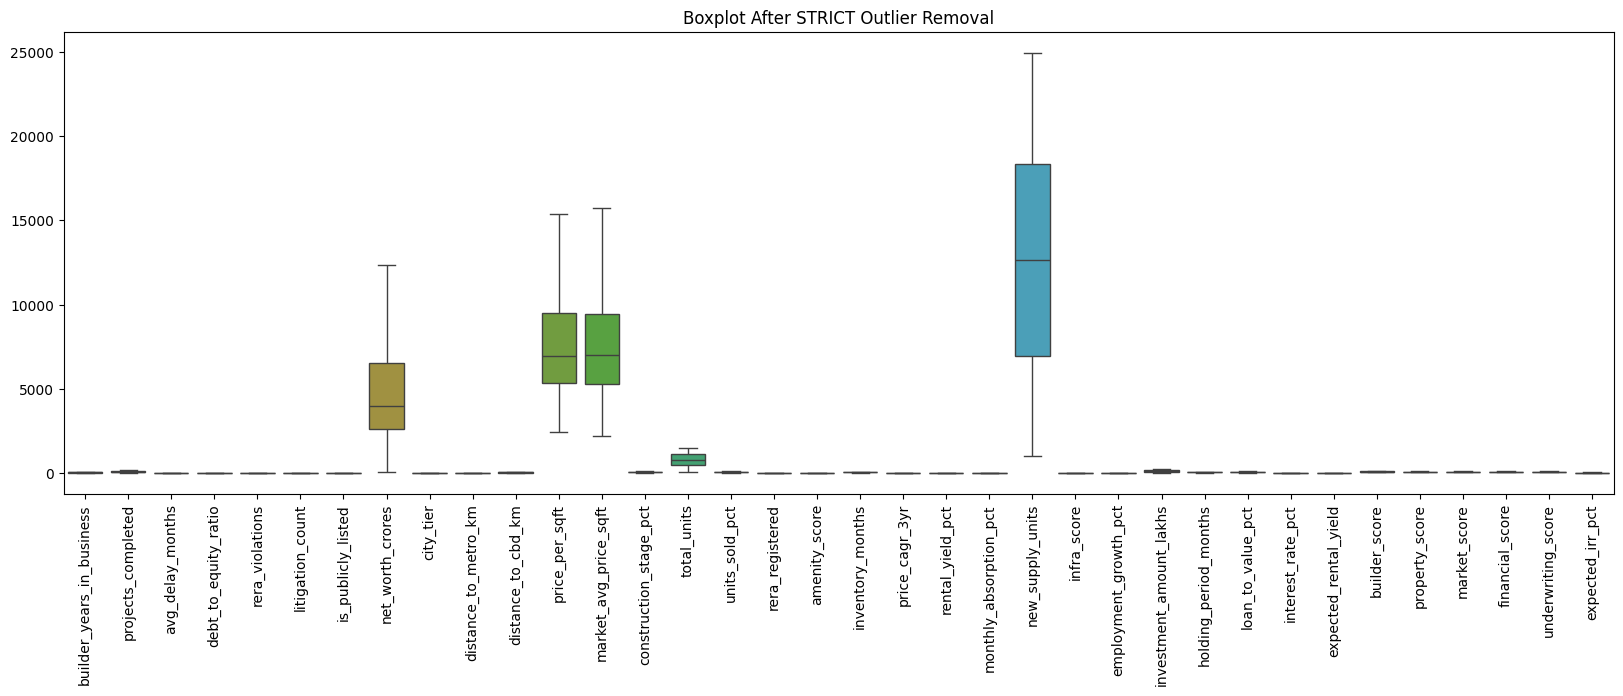

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data=df_clean[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot After STRICT Outlier Removal")
plt.show()

In [ ]:
import pandas as pd

# Start with your original dataframe
df_clean = df.copy()

# Select numeric columns
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

# Calculate IQR bounds
Q1 = df_clean[num_cols].quantile(0.25)
Q3 = df_clean[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# CAP THE VALUES: This makes the outliers 'disappear' by moving them to the bounds
for col in num_cols:
    df_clean[col] = df_clean[col].clip(lower=lower_bound[col], upper=upper_bound[col])

print("Shape after Capping:", df_clean.shape) # Still (500, 43)

Shape after Capping: (500, 43)


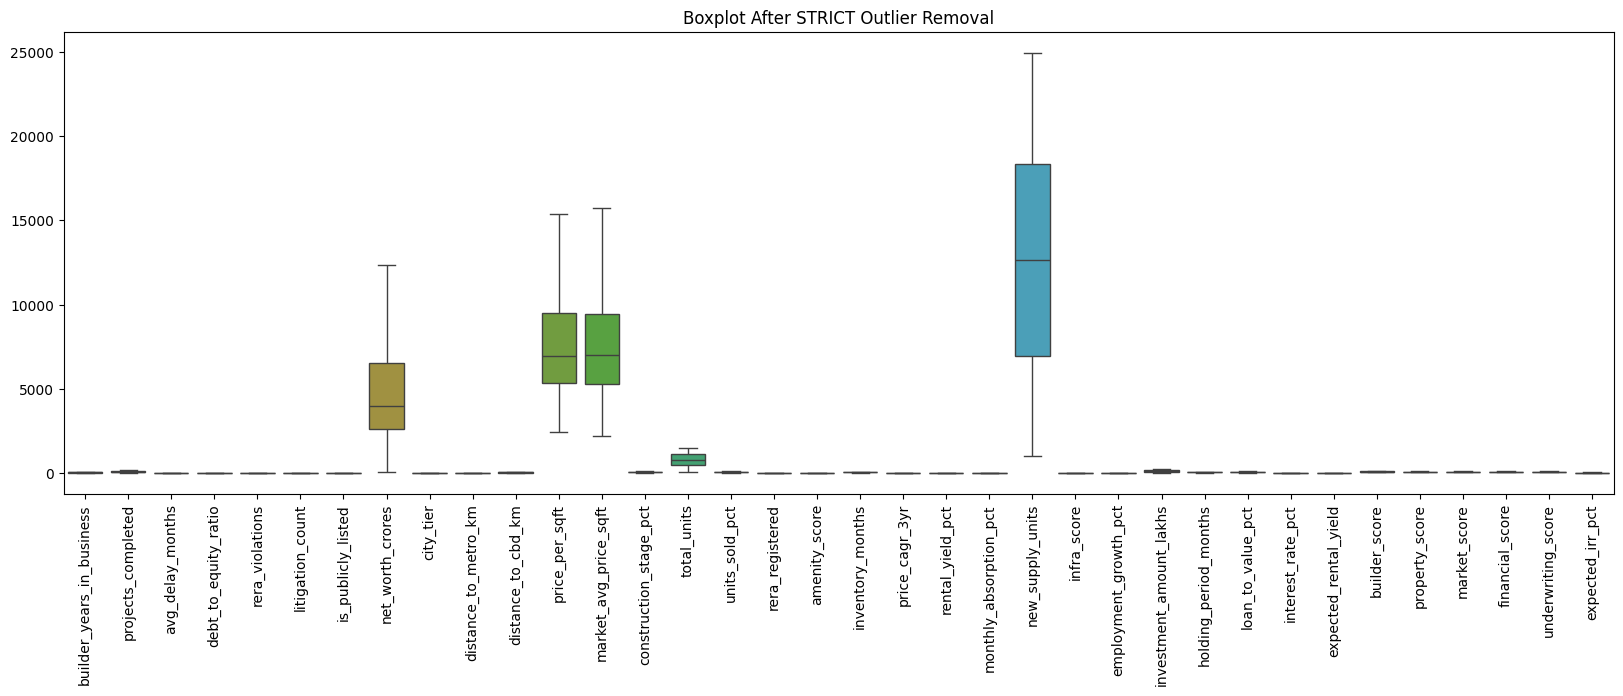

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data=df_clean[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot After STRICT Outlier Removal")
plt.show()

In [ ]:
import pandas as pd


df_clean = df.copy()


num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

Q1 = df_clean[num_cols].quantile(0.25)
Q3 = df_clean[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


for col in num_cols:
    df_clean[col] = df_clean[col].clip(lower=lower_bound[col], upper=upper_bound[col])


print("Final shape:", df_clean.shape)

Final shape: (500, 43)


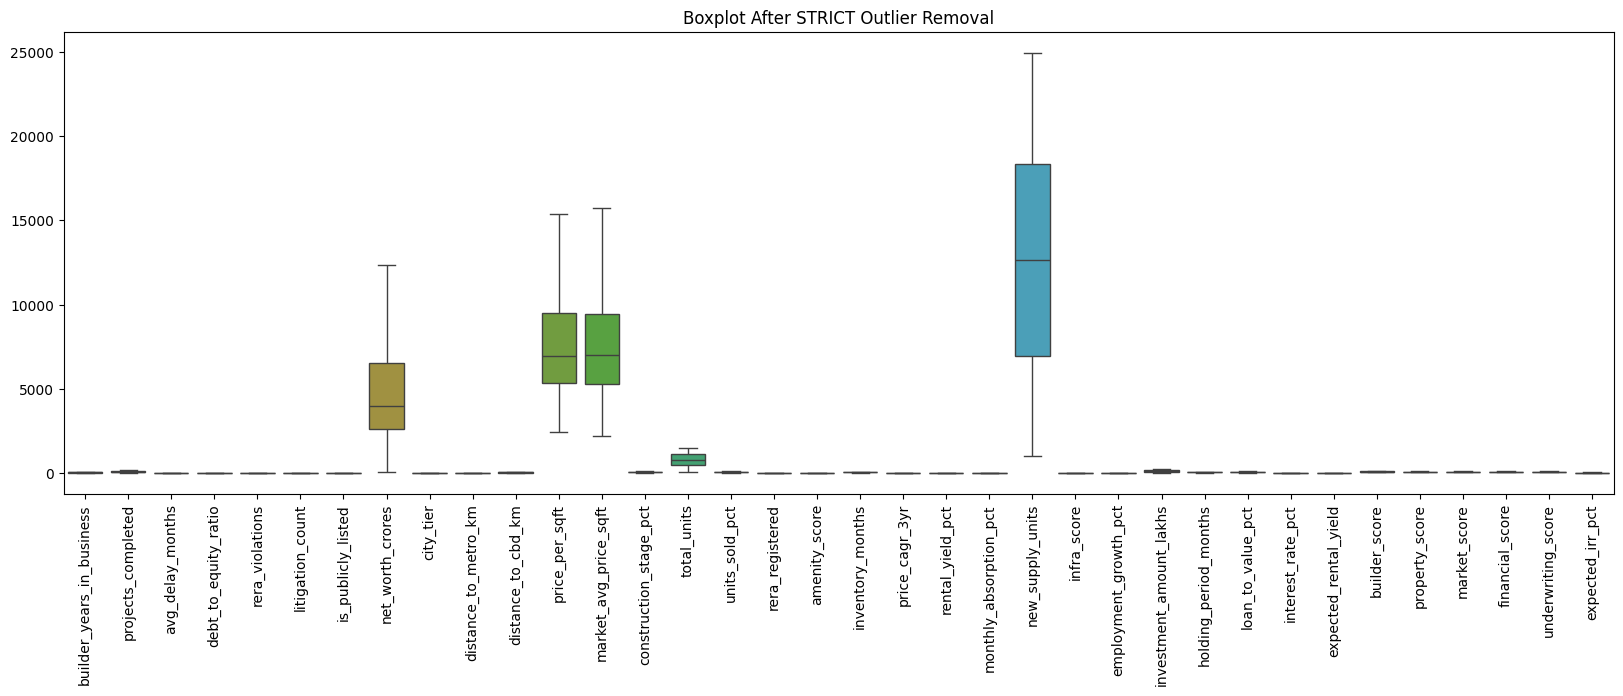

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data=df_clean[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot After STRICT Outlier Removal")
plt.show()

In [ ]:
df_model = df_clean.copy()

In [ ]:
final_path = "/content/drive/MyDrive/CF/task1_main/data/df_final_no_outliers.xlsx"

df_model.to_excel(final_path, index=False)

print(" Final dataset (no outliers) saved:")
print(final_path)

✅ Final dataset (no outliers) saved:
/content/drive/MyDrive/CF/task1_main/data/df_final_no_outliers.xlsx


In [ ]:
df_model.isnull().sum()

,0
property_id,0
city,0
builder_name,0
builder_years_in_business,0
projects_completed,0
avg_delay_months,0
debt_to_equity_ratio,0
rera_violations,0
litigation_count,0
is_publicly_listed,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df_model.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [ ]:
corr = df_model.corr(numeric_only=True)

target_corr = corr['underwriting_score'].abs().sort_values(ascending=False)

target_corr.head(25)

,underwriting_score
underwriting_score,1.000000
recommendation,0.887158
risk_category,0.731144
builder_score,0.707169
litigation_count,0.681336
debt_to_equity_ratio,0.678391
rera_violations,0.643918
avg_delay_months,0.640432
is_publicly_listed,0.526160
financial_score,0.409466


In [ ]:
top_21_features = [
    'litigation_count', 'market_score', 'property_score', 'builder_score',
    'financial_score', 'debt_to_equity_ratio', 'price_cagr_3yr', 'is_publicly_listed',
    'avg_delay_months', 'net_worth_crores', 'distance_to_cbd_km', 'rera_violations',
    'inventory_months', 'expected_rental_yield', 'distance_to_metro_km',
    'loan_to_value_pct', 'monthly_absorption_pct', 'projects_completed',
    'new_supply_units', 'builder_years_in_business'
]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

df = df_model.copy()

print("Original dataset size:", len(df))


target_size = 900
current_size = len(df)

if current_size >= target_size:
    df_expanded = df.copy()
    print("Dataset already >= target size")
else:
    n_samples_needed = target_size - current_size


    # Bootstrapping (sampling with replacement)

    df_synthetic = resample(
        df,
        replace=True,
        n_samples=n_samples_needed,
        random_state=42
    )


    # Add slight noise to numeric columns

    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    noise_scale = 0.01

    for col in num_cols:
        std_dev = df[col].std()

        if std_dev > 0:   # avoid noise on constant columns
            noise = np.random.normal(
                loc=0,
                scale=noise_scale * std_dev,
                size=len(df_synthetic)
            )

            df_synthetic[col] = df_synthetic[col] + noise


    # Combine original + synthetic

    df_expanded = pd.concat([df, df_synthetic], ignore_index=True)

print("Expanded dataset size:", len(df_expanded))

Original dataset size: 500
Expanded dataset size: 900


In [ ]:
print("Dataset shape:", df_expanded.shape)

Dataset shape: (900, 43)


In [ ]:
df_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   property_id                900 non-null    float64
 1   city                       900 non-null    float64
 2   builder_name               900 non-null    float64
 3   builder_years_in_business  900 non-null    float64
 4   projects_completed         900 non-null    float64
 5   avg_delay_months           900 non-null    float64
 6   debt_to_equity_ratio       900 non-null    float64
 7   rera_violations            900 non-null    float64
 8   litigation_count           900 non-null    float64
 9   is_publicly_listed         900 non-null    float64
 10  net_worth_crores           900 non-null    float64
 11  city_tier                  900 non-null    float64
 12  distance_to_metro_km       900 non-null    float64
 13  distance_to_cbd_km         900 non-null    float64

In [ ]:
df_expanded.describe()

,property_id,city,builder_name,builder_years_in_business,projects_completed,avg_delay_months,debt_to_equity_ratio,rera_violations,litigation_count,is_publicly_listed,...,payment_plan_type,builder_score,property_score,market_score,financial_score,underwriting_score,risk_category,expected_irr_pct,recommendation,confidence_level
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,...,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,246.409469,7.785250,13.780638,22.671575,63.314133,5.696871,1.328227,1.514534,2.908459,0.603314,...,0.565744,76.018681,59.645369,61.100254,64.516260,65.755385,3.353407,9.521320,1.523282,0.620822
std,143.248573,4.582282,8.609619,11.338873,49.266229,3.421962,0.605405,1.573546,2.424283,0.489459,...,0.785842,10.705070,8.322333,12.636498,12.451828,8.989283,0.973839,6.036756,0.670932,0.485391
min,-1.667436,-0.055445,-0.078335,1.876085,0.244474,0.000000,0.240000,-0.036448,-0.044986,-0.011385,...,-0.029429,55.747684,39.500000,29.336345,38.500000,46.036559,-0.005545,-5.600000,-0.011225,-0.012552
25%,125.750000,4.021608,6.000000,14.000000,22.818377,3.264815,0.905599,0.000000,1.000000,0.000000,...,0.000000,71.124017,54.500000,52.643254,55.500000,61.502451,3.000000,4.700000,1.000000,0.000000
50%,240.884142,7.064364,13.000000,23.078231,56.000000,5.109615,1.173853,1.000000,2.042530,0.998773,...,0.002109,77.500000,58.570414,61.000000,64.000000,66.800000,3.995659,9.437911,1.999322,0.998610
75%,369.921117,11.971323,21.000000,31.000000,84.719714,7.371277,1.600000,2.007006,4.000000,1.000000,...,1.000000,83.500000,64.500000,70.219773,74.000000,71.700000,4.000000,14.070227,2.000000,1.000000
max,499.297079,16.083703,29.073807,47.000000,182.263327,13.501869,2.559537,5.042299,8.544128,1.015665,...,2.017590,97.000000,79.699295,95.541754,95.000000,86.906108,4.027306,23.623513,2.017987,1.012131


In [ ]:
print("Duplicates:", df_expanded.duplicated().sum())

Duplicates: 0


In [ ]:
print("Total missing values:", df_expanded.isnull().sum().sum())

Total missing values: 0


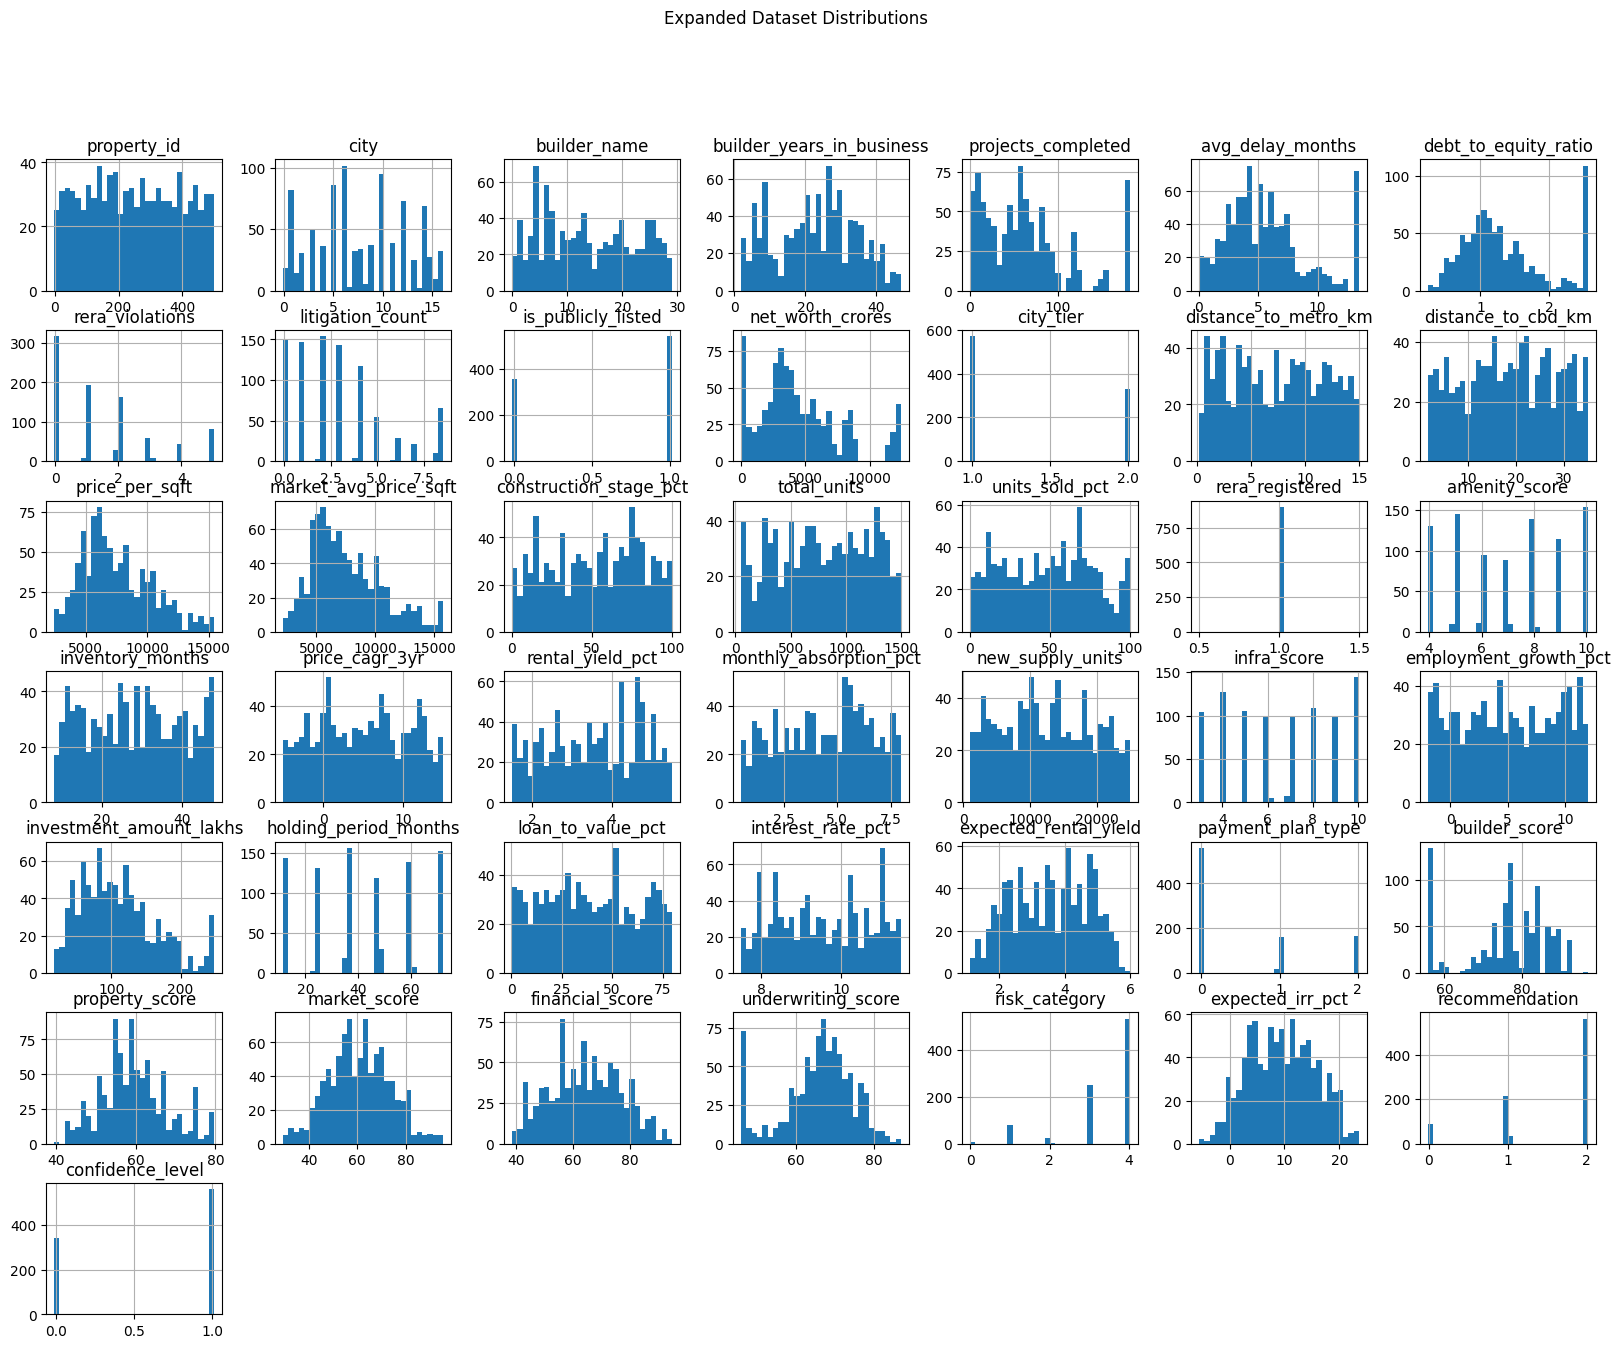

In [ ]:
df_expanded.hist(figsize=(20,15), bins=30)
plt.suptitle("Expanded Dataset Distributions")
plt.show()

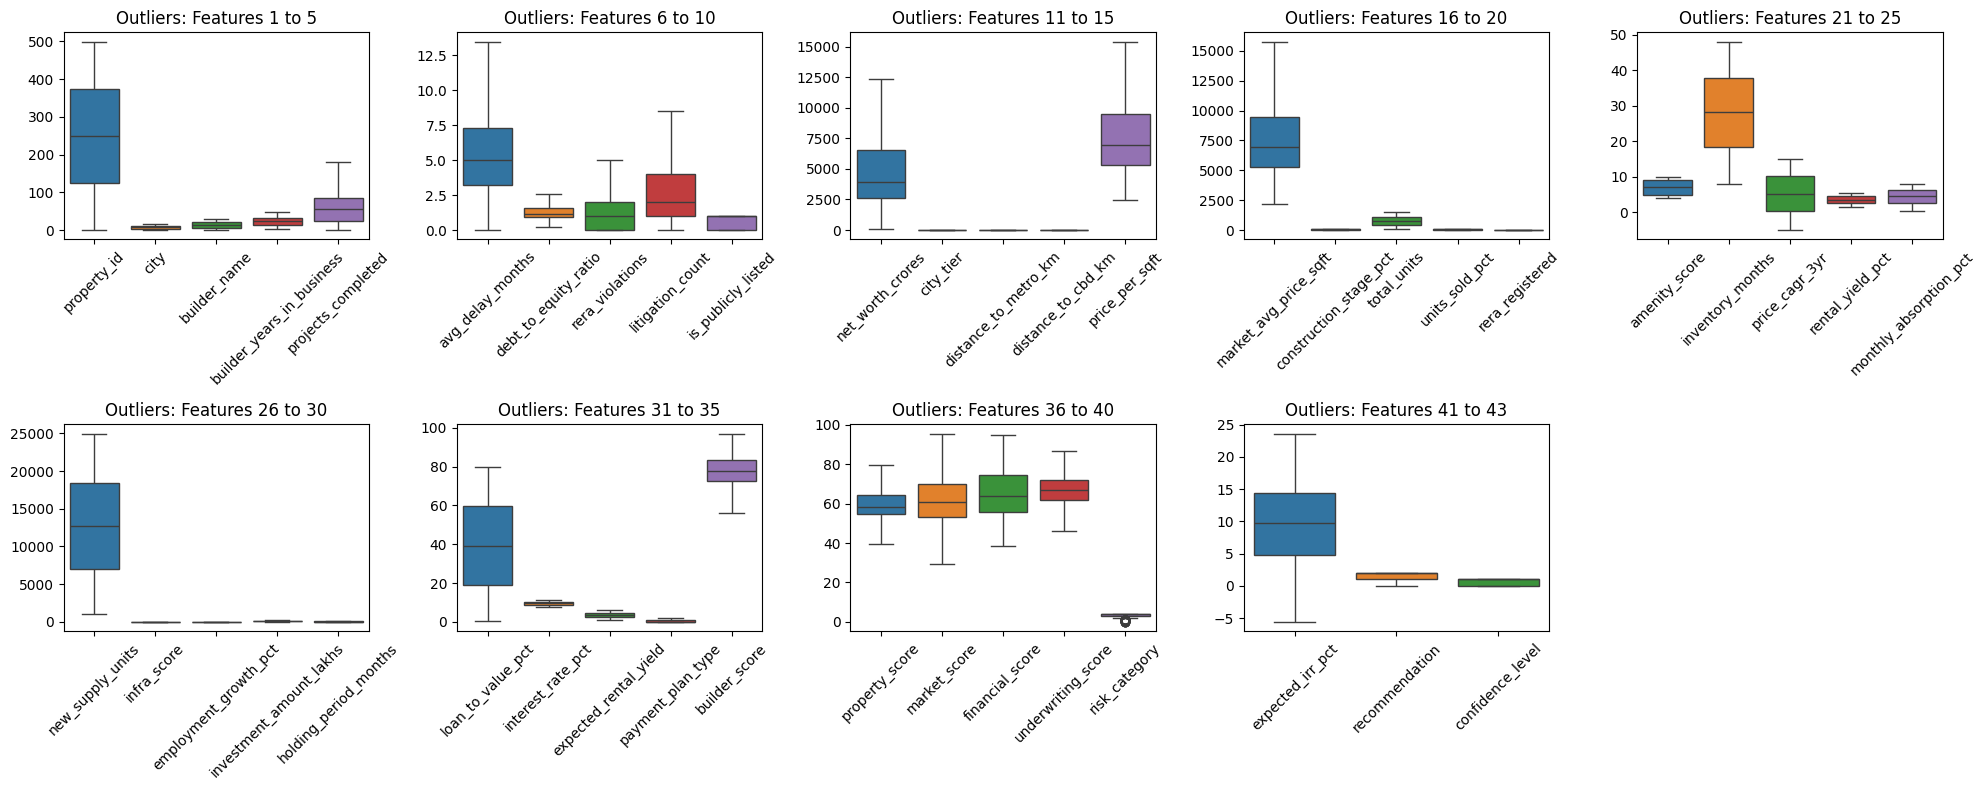

In [ ]:
##no need##copied from up##

import math
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64']).columns
batch_size = 5

# 1. Calculate how many total plots (batches) we need
num_batches = math.ceil(len(num_cols) / batch_size)

# 2. Define the grid layout (5 columns)
grid_cols = 5
grid_rows = math.ceil(num_batches / grid_cols)

# 3. Create the figure and the axes grid
# Increased width to 20 so the 5 columns aren't squished together
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 4 * grid_rows))

# Flatten the axes array to make it easy to loop through
# (Ensures it works whether grid_rows is 1 or more)
import numpy as np
axes = np.array(axes).flatten()

for i in range(num_batches):
    start_idx = i * batch_size
    batch = num_cols[start_idx : start_idx + batch_size]

    # 4. Draw the plot on the specific axis (axes[i])
    sns.boxplot(data=df[batch], ax=axes[i])

    # 5. Set titles and tick rotations for the specific axis
    axes[i].set_title(f"Outliers: Features {start_idx+1} to {start_idx+len(batch)}")
    axes[i].tick_params(axis='x', rotation=45)

# 6. Hide any extra empty subplots if the grid isn't perfectly filled
for j in range(num_batches, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [ ]:
output_path = "/content/drive/MyDrive/CF/task1_main/data/df_expanded_900.xlsx"

df_expanded.to_excel(output_path, index=False)

print(" Expanded dataset saved successfully!")
print("Location:", output_path)

 Expanded dataset saved successfully!
Location: /content/drive/MyDrive/CF/task1_main/data/df_expanded_900.xlsx


In [ ]:
df_model = df_expanded.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df_model.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [ ]:
top_21_features = [
    'litigation_count', 'market_score', 'property_score', 'builder_score',
    'financial_score', 'debt_to_equity_ratio', 'price_cagr_3yr', 'is_publicly_listed',
    'avg_delay_months', 'net_worth_crores', 'distance_to_cbd_km', 'rera_violations',
    'inventory_months', 'expected_rental_yield', 'distance_to_metro_km',
    'loan_to_value_pct', 'monthly_absorption_pct', 'projects_completed',
    'new_supply_units', 'builder_years_in_business'
]


In [ ]:
X = df_model[top_21_features]

y_reg = df_model['underwriting_score']
y_clf = df_model['risk_category']

In [ ]:
from sklearn.model_selection import train_test_split

# Regression
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)

lr_preds = lr.predict(X_test_scaled)

print(" Linear Regression Results")
print("MAE :", mean_absolute_error(y_test_reg, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, lr_preds)))
print("R²  :", r2_score(y_test_reg, lr_preds))

 Linear Regression Results
MAE : 1.7236049389715662
RMSE: 2.3303274540125094
R²  : 0.9344863414036687


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train_reg)

dt_preds = dt.predict(X_test)

print(" Decision Tree Regressor Results")
print("MAE :", mean_absolute_error(y_test_reg, dt_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, dt_preds)))
print("R²  :", r2_score(y_test_reg, dt_preds))

 Decision Tree Regressor Results
MAE : 1.721792498352507
RMSE: 3.0914036183334477
R²  : 0.8847052925662118


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train_reg)

rf_preds = rf.predict(X_test)

print(" Random Forest Regressor Results")
print("MAE :", mean_absolute_error(y_test_reg, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, rf_preds)))
print("R²  :", r2_score(y_test_reg, rf_preds))

 Random Forest Regressor Results
MAE : 1.2500768667139666
RMSE: 1.7915672191377612
R²  : 0.9612774307929861


In [ ]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train_scaled, y_train_reg)

svr_preds = svr.predict(X_test_scaled)

print(" Support Vector Regressor Results")
print("MAE :", mean_absolute_error(y_test_reg, svr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, svr_preds)))
print("R²  :", r2_score(y_test_reg, svr_preds))

 Support Vector Regressor Results
MAE : 1.7506535674422208
RMSE: 2.5127884592313494
R²  : 0.9238254657869281


In [ ]:
print(df_model['risk_category'].dtype)
print(df_model['risk_category'].head(10))
print(df_model['risk_category'].unique())

float64
0    4.0
1    1.0
2    4.0
3    1.0
4    4.0
5    3.0
6    4.0
7    4.0
8    1.0
9    4.0
Name: risk_category, dtype: float64
[ 4.00000000e+00  1.00000000e+00  3.00000000e+00  2.00000000e+00
  0.00000000e+00  4.00121783e+00  4.02397204e+00  3.98800973e+00
  4.01190070e+00  4.00748776e+00  2.99003645e+00  3.98172026e+00
  3.99225271e+00  4.01081469e+00  3.99967029e+00  4.01282193e+00
  3.99664537e+00  2.98772103e+00  4.00176720e+00  4.00089213e+00
  2.99971391e+00  4.00463947e+00  1.00547324e+00  2.99254981e+00
  4.01018483e+00  3.98850921e+00  2.98288795e+00  2.98603750e+00
  3.99675139e+00  3.00066719e+00  9.93990367e-01  3.99497330e+00
  4.00124391e+00  3.01308129e+00  3.98363886e+00  4.00938460e+00
  4.01537256e+00  3.98140051e+00  4.00213941e+00  3.99764865e+00
  3.98753673e+00  4.00091280e+00  3.99640728e+00  2.99393729e+00
  4.00380426e+00  3.98973770e+00  3.34889960e-03  9.93246676e-01
  9.99673677e-01  9.88861572e-01  4.00380802e+00  4.01377623e+00
  2.97980090e+00  4.0

In [ ]:
# Step 1: Round values
df_model['risk_category'] = df_model['risk_category'].round()

# Step 2: Clip into valid class range (adjust if needed)
df_model['risk_category'] = df_model['risk_category'].clip(0, 4)

# Step 3: Convert to integer
df_model['risk_category'] = df_model['risk_category'].astype(int)

print(" risk_category FIXED")
print("Datatype:", df_model['risk_category'].dtype)
print("Unique classes:", sorted(df_model['risk_category'].unique()))

 risk_category FIXED
Datatype: int64
Unique classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [ ]:
X = df_model[top_21_features]
y_clf = df_model['risk_category']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

print(" Pipeline rebuilt")

 Pipeline rebuilt


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_clf_scaled, y_train_clf)

log_preds = log_reg.predict(X_test_clf_scaled)

print(" Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test_clf, log_preds))
print(classification_report(y_test_clf, log_preds))

 Logistic Regression Results
Accuracy: 0.8833333333333333
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.70      0.88      0.78        16
           2       1.00      0.29      0.44         7
           3       0.90      0.84      0.87        55
           4       0.91      0.97      0.94       100

    accuracy                           0.88       180
   macro avg       0.70      0.59      0.61       180
weighted avg       0.88      0.88      0.87       180



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_clf, y_train_clf)

dt_clf_preds = dt_clf.predict(X_test_clf)

print(" Decision Tree Classifier Results")
print("Accuracy:", accuracy_score(y_test_clf, dt_clf_preds))
print(classification_report(y_test_clf, dt_clf_preds))

 Decision Tree Classifier Results
Accuracy: 0.8444444444444444
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.83      0.94      0.88        16
           2       0.43      0.43      0.43         7
           3       0.87      0.82      0.84        55
           4       0.87      0.88      0.88       100

    accuracy                           0.84       180
   macro avg       0.70      0.71      0.71       180
weighted avg       0.84      0.84      0.84       180



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)

rf_clf_preds = rf_clf.predict(X_test_clf)

print(" Random Forest Classifier Results")
print("Accuracy:", accuracy_score(y_test_clf, rf_clf_preds))
print(classification_report(y_test_clf, rf_clf_preds))

 Random Forest Classifier Results
Accuracy: 0.9222222222222223
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.94      1.00      0.97        16
           2       1.00      0.43      0.60         7
           3       0.98      0.85      0.91        55
           4       0.89      0.99      0.94       100

    accuracy                           0.92       180
   macro avg       0.96      0.75      0.82       180
weighted avg       0.93      0.92      0.92       180



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)

rf_clf_preds = rf_clf.predict(X_test_clf)

print(" Random Forest Classifier Results")
print("Accuracy:", accuracy_score(y_test_clf, rf_clf_preds))
print(classification_report(y_test_clf, rf_clf_preds))

 Random Forest Classifier Results
Accuracy: 0.9222222222222223
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.94      1.00      0.97        16
           2       1.00      0.43      0.60         7
           3       0.98      0.85      0.91        55
           4       0.89      0.99      0.94       100

    accuracy                           0.92       180
   macro avg       0.96      0.75      0.82       180
weighted avg       0.93      0.92      0.92       180



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svc = SVC()
svc.fit(X_train_clf_scaled, y_train_clf)

svc_preds = svc.predict(X_test_clf_scaled)

print(" SVC trained successfully")
print("Accuracy:", accuracy_score(y_test_clf, svc_preds))

 SVC trained successfully
Accuracy: 0.9333333333333333


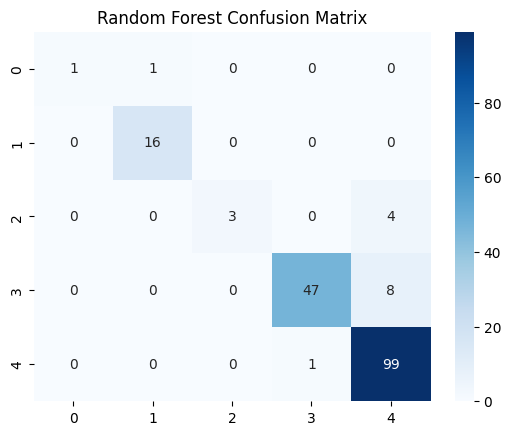

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_clf, rf_clf_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgb_reg = lgb.LGBMRegressor(random_state=42)

lgb_reg.fit(X_train, y_train_reg)

lgb_reg_preds = lgb_reg.predict(X_test)

print(" LightGBM Regressor Results")
print("MAE :", mean_absolute_error(y_test_reg, lgb_reg_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, lgb_reg_preds)))
print("R²  :", r2_score(y_test_reg, lgb_reg_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000352 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4691
[LightGBM] [Info] Number of data points in the train set: 720, number of used features: 20
[LightGBM] [Info] Start training from score 65.828756
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
lgb_clf = lgb.LGBMClassifier(random_state=42)

lgb_clf.fit(X_train_clf, y_train_clf)

lgb_clf_preds = lgb_clf.predict(X_test_clf)

print(" LightGBM Classifier Results")
print("Accuracy:", accuracy_score(y_test_clf, lgb_clf_preds))
print(classification_report(y_test_clf, lgb_clf_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4691
[LightGBM] [Info] Number of data points in the train set: 720, number of used features: 20
[LightGBM] [Info] Start training from score -4.633341
[LightGBM] [Info] Start training from score -2.404864
[LightGBM] [Info] Start training from score -3.583519
[LightGBM] [Info] Start training from score -1.311393
[LightGBM] [Info] Start training from score -0.506207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [ ]:
import pandas as pd

regression_scores = {
    "Linear Regression": r2_score(y_test_reg, lr_preds),
    "Decision Tree": r2_score(y_test_reg, dt_preds),
    "Random Forest": r2_score(y_test_reg, rf_preds),
    "SVR": r2_score(y_test_reg, svr_preds),
    "LightGBM": r2_score(y_test_reg, lgb_reg_preds)
}

reg_df = pd.DataFrame.from_dict(
    regression_scores, orient='index', columns=['R2 Score']
)

reg_df

,R2 Score
Linear Regression,0.934486
Decision Tree,0.884705
Random Forest,0.961277
SVR,0.923825
LightGBM,0.978384


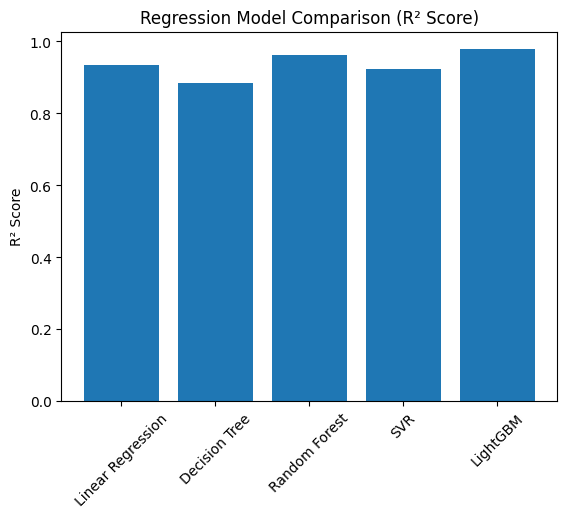

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(reg_df.index, reg_df['R2 Score'])
plt.xticks(rotation=45)
plt.title("Regression Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

In [ ]:
classification_scores = {
    "Logistic Regression": accuracy_score(y_test_clf, log_preds),
    "Decision Tree": accuracy_score(y_test_clf, dt_clf_preds),
    "Random Forest": accuracy_score(y_test_clf, rf_clf_preds),
    "SVC": accuracy_score(y_test_clf, svc_preds),
    "LightGBM": accuracy_score(y_test_clf, lgb_clf_preds)
}

clf_df = pd.DataFrame.from_dict(
    classification_scores, orient='index', columns=['Accuracy']
)

clf_df

,Accuracy
Logistic Regression,0.883333
Decision Tree,0.844444
Random Forest,0.922222
SVC,0.933333
LightGBM,0.911111


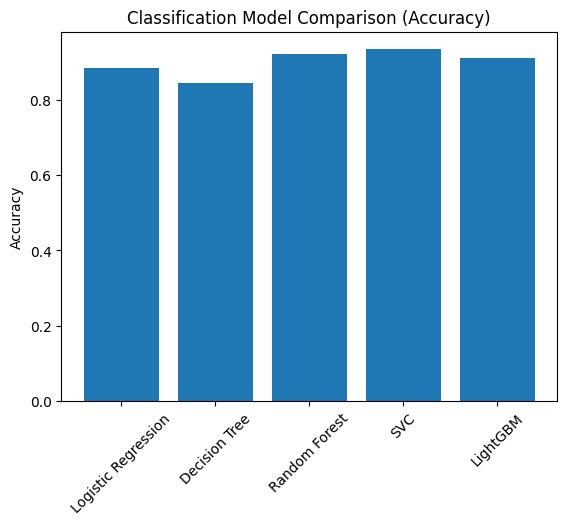

In [ ]:
plt.figure()
plt.bar(clf_df.index, clf_df['Accuracy'])
plt.xticks(rotation=45)
plt.title("Classification Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
comparison_df = pd.concat([reg_df, clf_df], axis=1)
comparison_df

,R2 Score,Accuracy
Linear Regression,0.934486,NaN
Decision Tree,0.884705,0.844444
Random Forest,0.961277,0.922222
SVR,0.923825,NaN
LightGBM,0.978384,0.911111
Logistic Regression,NaN,0.883333
SVC,NaN,0.933333


In [ ]:
print("Best Regression Model:", reg_df['R2 Score'].idxmax())
print("Best Classification Model:", clf_df['Accuracy'].idxmax())

Best Regression Model: LightGBM
Best Classification Model: SVC


In [ ]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 10]
}

lgb_reg = lgb.LGBMRegressor(random_state=42)

grid_lgbm = GridSearchCV(
    estimator=lgb_reg,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train_reg)

print(" Best Parameters:", grid_lgbm.best_params_)
print(" Best R²:", grid_lgbm.best_score_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4691
[LightGBM] [Info] Number of data points in the train set: 720, number of used features: 20
[LightGBM] [Info] Start training from score 65.828756
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
from sklearn.svm import SVC

param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svc = SVC()

grid_svc = GridSearchCV(
    estimator=svc,
    param_grid=param_grid_svc,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svc.fit(X_train_clf_scaled, y_train_clf)

print(" Best Parameters:", grid_svc.best_params_)
print(" Best Accuracy:", grid_svc.best_score_)

✅ Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
✅ Best Accuracy: 0.9249999999999999


In [ ]:
import os

model_dir = "/content/drive/MyDrive/CF/task1_main/models"

os.makedirs(model_dir, exist_ok=True)

print(" Directory ready:", model_dir)

 Directory ready: /content/drive/MyDrive/CF/task1_main/models


In [ ]:
import joblib

joblib.dump(lgb_reg, f"{model_dir}/lightgbm_regressor.pkl")

print(" LightGBM saved successfully!")

 LightGBM saved successfully!


In [ ]:
joblib.dump(svc, f"{model_dir}/svc_classifier.pkl")

print(" SVC saved successfully!")

 SVC saved successfully!


In [ ]:
joblib.dump(scaler, f"{model_dir}/scaler.pkl")

['/content/drive/MyDrive/CF/task1_main/models/scaler.pkl']

In [ ]:
joblib.dump(top_21_features, f"{model_dir}/feature_list.pkl")

['/content/drive/MyDrive/CF/task1_main/models/feature_list.pkl']

In [ ]:
print(os.listdir(model_dir))

['lightgbm_regressor.pkl', 'svc_classifier.pkl', 'scaler.pkl', 'feature_list.pkl']


In [ ]:
import lightgbm as lgb

lgb_reg = lgb.LGBMRegressor(random_state=42)

lgb_reg.fit(X_train, y_train_reg)

print(" LightGBM trained successfully")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4691
[LightGBM] [Info] Number of data points in the train set: 720, number of used features: 20
[LightGBM] [Info] Start training from score 65.828756
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
df_model['predicted_underwriting_score'] = lgb_reg.predict(X)

df_model[['underwriting_score', 'predicted_underwriting_score']].head()

,underwriting_score,predicted_underwriting_score
0,70.5000,70.618973
1,46.1875,46.035845
2,68.8000,68.368836
3,46.1875,46.020004
4,74.2000,74.399085


In [ ]:
def assign_risk_category(score):
    if score >= 80:
        return "Low Risk"
    elif score >= 65:
        return "Moderate Risk"
    elif score >= 50:
        return "Medium Risk"
    elif score >= 35:
        return "High Risk"
    else:
        return "Very High Risk"

df_model['predicted_risk_category'] = df_model['predicted_underwriting_score'].apply(assign_risk_category)

df_model[['predicted_underwriting_score', 'predicted_risk_category']].head()

,predicted_underwriting_score,predicted_risk_category
0,70.618973,Moderate Risk
1,46.035845,High Risk
2,68.368836,Moderate Risk
3,46.020004,High Risk
4,74.399085,Moderate Risk


In [ ]:
def generate_recommendation(risk):
    if risk == "Low Risk":
        return "INVEST"
    elif risk == "Moderate Risk":
        return "INVEST"
    elif risk == "Medium Risk":
        return "HOLD"
    else:
        return "AVOID"

df_model['recommendation'] = df_model['predicted_risk_category'].apply(generate_recommendation)

df_model[['predicted_risk_category', 'recommendation']].head()

,predicted_risk_category,recommendation
0,Moderate Risk,INVEST
1,High Risk,AVOID
2,Moderate Risk,INVEST
3,High Risk,AVOID
4,Moderate Risk,INVEST


In [ ]:
# Absolute prediction error
df_model['prediction_error'] = abs(
    df_model['underwriting_score'] - df_model['predicted_underwriting_score']
)

def confidence_level(error):
    if error < 3:
        return "High Confidence"
    elif error < 7:
        return "Medium Confidence"
    else:
        return "Low Confidence"

df_model['confidence_level'] = df_model['prediction_error'].apply(confidence_level)

df_model[['prediction_error', 'confidence_level']].head()

,prediction_error,confidence_level
0,0.118973,High Confidence
1,0.151655,High Confidence
2,0.431164,High Confidence
3,0.167496,High Confidence
4,0.199085,High Confidence


In [ ]:
df_model[[
    'predicted_underwriting_score',
    'predicted_risk_category',
    'recommendation',
    'confidence_level'
]].head()

,predicted_underwriting_score,predicted_risk_category,recommendation,confidence_level
0,70.618973,Moderate Risk,INVEST,High Confidence
1,46.035845,High Risk,AVOID,High Confidence
2,68.368836,Moderate Risk,INVEST,High Confidence
3,46.020004,High Risk,AVOID,High Confidence
4,74.399085,Moderate Risk,INVEST,High Confidence


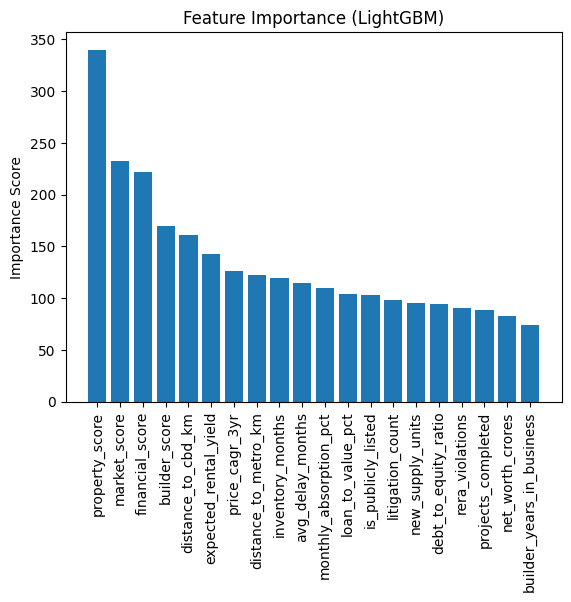

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    lgb_reg.feature_importances_,
    index=top_21_features
).sort_values(ascending=False)

plt.figure()
plt.bar(importance.index, importance.values)
plt.xticks(rotation=90)
plt.title("Feature Importance (LightGBM)")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
top_features = importance.head(10)

print(" Top Features Driving Underwriting Score:")
print(top_features)

 Top Features Driving Underwriting Score:
property_score           340
market_score             233
financial_score          222
builder_score            170
distance_to_cbd_km       161
expected_rental_yield    143
price_cagr_3yr           126
distance_to_metro_km     122
inventory_months         120
avg_delay_months         115
dtype: int32
